# **Generate KdV Data**

In [1]:
# Core
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from netCDF4 import Dataset
from sangkuriang_ideal.cli import run_scenario
from sangkuriang_ideal.io.config_manager import ConfigManager

# sangkuriang_ideal needs numpy<2.0, but np.trapz was renamed to np.trapezoid in numpy 2.0
if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid

#### **ONE EXACT SOLITON**

In [6]:
# Plot settings
import matplotlib
%matplotlib inline

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100
#plt.rcParams['figure.dpi'] = 300

matplotlib.rc('xtick', labelsize=10, direction='out')
matplotlib.rc('ytick', labelsize=10, direction='out')

u: (200, 1024) energy_error = 1.05e-14


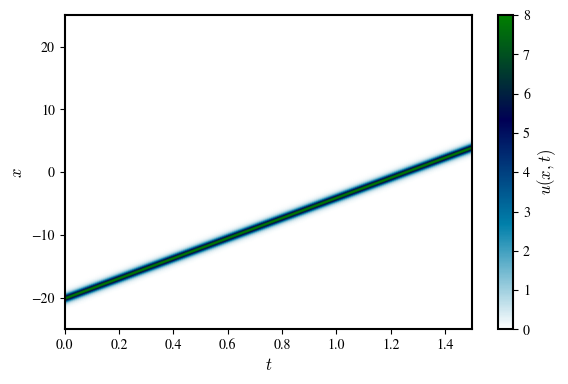

In [7]:
config = ConfigManager.load("configs/kdv_single_soliton_v0.txt")

if not os.path.exists("outputs/kdv_single_soliton_v0.nc"):
    run_scenario(config, output_dir="outputs", verbose=True, n_cores=None)

with Dataset("outputs/kdv_single_soliton_v0.nc") as nc:
    x = nc["x"][:].data
    t = nc["t"][:].data
    u = nc["u"][:].data
    print("u:", u.shape, f"energy_error = {nc.energy_error:.2e}")

# Plot er up
fig, ax = plt.subplots(1, figsize=(6,4))

pc = ax.pcolormesh(t,x,u.T, cmap="ocean_r", shading="gouraud")
ax.set_xlabel("$t$")
ax.set_ylabel("$x$")
#ax.set_ylim([-18,14])
fig.colorbar(pc, ax=ax, label="$u(x,t)$")

plt.tight_layout()
plt.show()

kdv_single_soliton_v1: u: (200, 1024) | energy_error = 1.11e-14
kdv_single_soliton_v2: u: (200, 1024) | energy_error = 2.48e-14


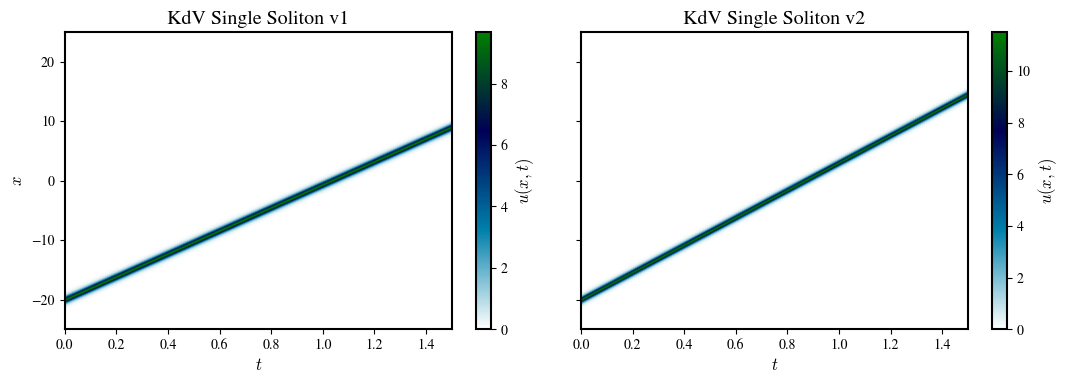

In [8]:
# Also generate two nearby trajectories (v1 uses kappa = 2.2, v2 uses kappa = 2.4)
nearby_sims = ["kdv_single_soliton_v1", "kdv_single_soliton_v2"]

fig, axes = plt.subplots(1, len(nearby_sims), figsize=(11, 4), sharey=True)

for name, ax in zip(nearby_sims, axes):
    config = ConfigManager.load(f"configs/{name}.txt")
    output = f"outputs/{name}.nc"

    if not os.path.exists(output):
        run_scenario(config, output_dir="outputs", verbose=True, n_cores=None)

    with Dataset(output) as nc:
        x = nc["x"][:].data
        t = nc["t"][:].data
        u = nc["u"][:].data
        print(f"{name}: u: {u.shape} | energy_error = {nc.energy_error:.2e}")

    pc = ax.pcolormesh(t, x, u.T, cmap="ocean_r", shading="gouraud")
    ax.set_xlabel("$t$")
    ax.set_title(config["scenario_name"])
    #ax.set_ylim([-18, 14])
    fig.colorbar(pc, ax=ax, label="$u(x,t)$")

axes[0].set_ylabel("$x$")

plt.tight_layout()
plt.show()

#### **TWO-SOLITON COLLISION**

In [12]:
# Plot settings
import matplotlib
%matplotlib inline

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100
#plt.rcParams['figure.dpi'] = 300

matplotlib.rc('xtick', labelsize=10, direction='out')
matplotlib.rc('ytick', labelsize=10, direction='out')

u: (200, 1024) | energy_error = 1.02e-14


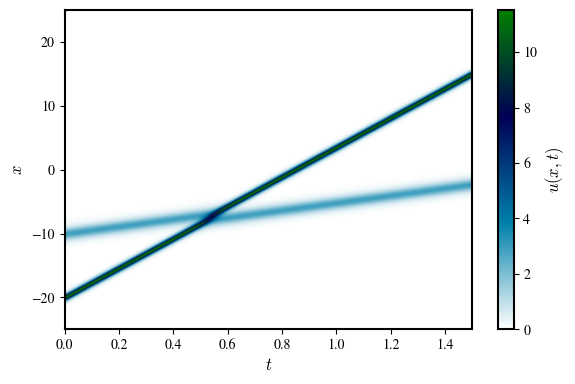

In [13]:
from netCDF4 import Dataset

if not os.path.exists("outputs/kdv_soliton_collision_v0.nc"):
    config = ConfigManager.load("configs/kdv_soliton_collision_v0.txt")
    run_scenario(config, output_dir="outputs", verbose=True, n_cores=None)

with Dataset("outputs/kdv_soliton_collision_v0.nc") as nc:
    x = nc["x"][:].data
    t = nc["t"][:].data
    u = nc["u"][:].data
    print("u:", u.shape, f"| energy_error = {nc.energy_error:.2e}")

fig, ax = plt.subplots(1, figsize=(6,4))

# Plot that pup
pc = ax.pcolormesh(t,x,u.T, cmap="ocean_r", shading="gouraud")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x$")
#ax.set_ylim([-18,14])
fig.colorbar(pc, ax=ax, label=r"$u(x,t)$")

plt.tight_layout()
plt.show()

kdv_soliton_collision_v1: u: (200, 1024) | energy_error = 8.38e-15
kdv_soliton_collision_v2: u: (200, 1024) | energy_error = 1.50e-14


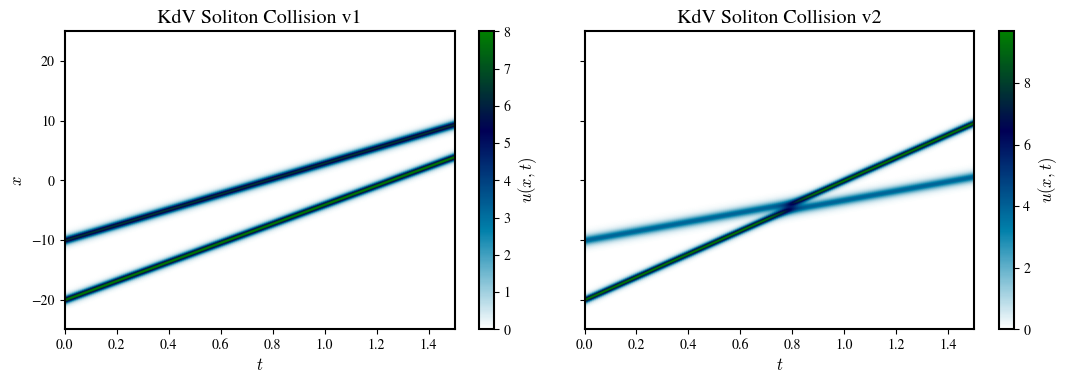

In [14]:
# Also generate two nearby trajectories (v1 uses kappas = (2.0,1.8), v2 uses kappas = (2.2,1.4))
nearby_collisions = ["kdv_soliton_collision_v1", "kdv_soliton_collision_v2"]
nearby_configs = ["configs/kdv_soliton_collision_v1.txt", "configs/kdv_soliton_collision_v2.txt"]

fig, axes = plt.subplots(1, len(nearby_collisions), figsize=(11, 4), sharey=True)

for name, cfg_path, ax in zip(nearby_collisions, nearby_configs, axes):
    config = ConfigManager.load(cfg_path)
    output = f"outputs/{name}.nc"

    if not os.path.exists(output):
        run_scenario(config, output_dir="outputs", verbose=True, n_cores=None)

    with Dataset(output) as nc:
        x = nc["x"][:].data
        t = nc["t"][:].data
        u = nc["u"][:].data
        print(f"{name}: u: {u.shape} | energy_error = {nc.energy_error:.2e}")

    pc = ax.pcolormesh(t, x, u.T, cmap="ocean_r", shading="gouraud")
    ax.set_xlabel(r"$t$")
    ax.set_title(config["scenario_name"])
    #ax.set_ylim([-18, 14])
    fig.colorbar(pc, ax=ax, label=r"$u(x,t)$")

axes[0].set_ylabel(r"$x$")

plt.tight_layout()
plt.show()

#### **ONE SOLITON (PERTURBED)**

In [18]:
# Plot settings
import matplotlib
%matplotlib inline

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100
#plt.rcParams['figure.dpi'] = 300

matplotlib.rc('xtick', labelsize=10, direction='out')
matplotlib.rc('ytick', labelsize=10, direction='out')

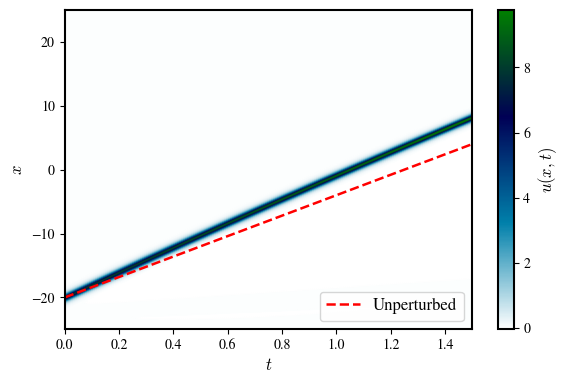

In [19]:
from perturbed_kdv_solver import load_config, run_perturbed_scenario

perturbed_config = load_config("configs/kdv_single_soliton_perturbed_v0.txt")
perturbed_output = "outputs/kdv_single_soliton_perturbed_v0.nc"

if not os.path.exists(perturbed_output):
    run_perturbed_scenario(perturbed_config, output_dir="outputs", verbose=True, n_cores=None)

with Dataset(perturbed_output) as nc:
    x = nc["x"][:].data
    t = nc["t"][:].data
    u = nc["u"][:].data
    eta = nc.eta
    equation = nc.equation
    mass_error = nc.mass_error
    momentum_error = nc.momentum_error
    energy_error = nc.energy_error

# Compare to unperturbed case
unperturbed_speed = perturbed_config["eps"]*perturbed_config["amplitude"]/3.0
unperturbed_path = perturbed_config["position"] + unperturbed_speed*t

# Plot this perturbed puppy
fig, ax = plt.subplots(1, figsize=(6,4))

pc = ax.pcolormesh(t,x,u.T, cmap="ocean_r", shading="gouraud")
ax.plot(t, unperturbed_path, color="red", lw=1.8, linestyle="--", label="Unperturbed")
ax.set_xlabel("$t$")
ax.set_ylabel("$x$")
#ax.set_ylim([-18,14])
ax.legend(loc="lower right")
fig.colorbar(pc, ax=ax, label="$u(x,t)$")

plt.tight_layout()
plt.show()

kdv_single_soliton_perturbed_v1: u: (200, 1024) | energy_error = 6.48e-01
kdv_single_soliton_perturbed_v2: u: (200, 1024) | energy_error = 6.48e-01


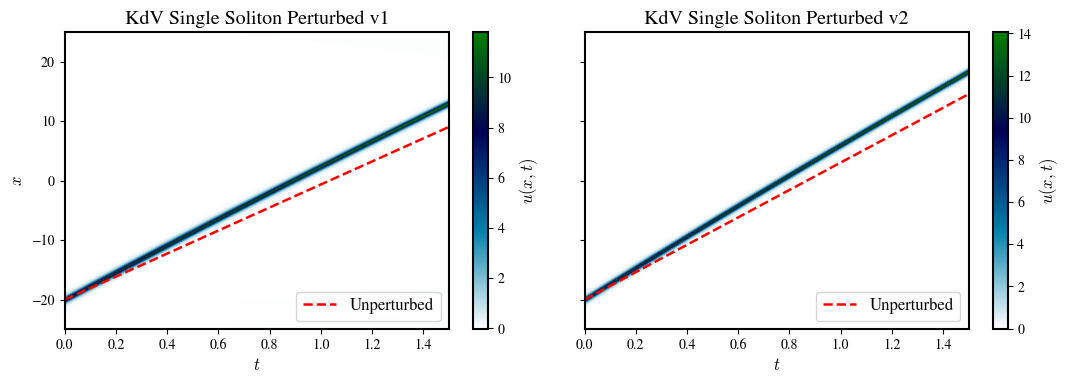

In [20]:
# Also generate two nearby perturbed trajectories (v1 uses kappa = 2.2, v2 uses kappa = 2.4)
nearby_perturbed = ["kdv_single_soliton_perturbed_v1", "kdv_single_soliton_perturbed_v2"]

fig, axes = plt.subplots(1, len(nearby_perturbed), figsize=(11, 4), sharey=True)

for name, ax in zip(nearby_perturbed, axes):
    config = load_config(f"configs/{name}.txt")
    output = f"outputs/{name}.nc"

    if not os.path.exists(output):
        run_perturbed_scenario(config, output_dir="outputs", verbose=True, n_cores=None)

    with Dataset(output) as nc:
        x = nc["x"][:].data
        t = nc["t"][:].data
        u = nc["u"][:].data
        print(f"{name}: u: {u.shape} | energy_error = {nc.energy_error:.2e}")

    # Compare to unperturbed case
    unperturbed_speed = config["eps"]*config["amplitude"]/3.0
    unperturbed_path = config["position"] + unperturbed_speed*t

    pc = ax.pcolormesh(t, x, u.T, cmap="ocean_r", shading="gouraud")
    ax.plot(t, unperturbed_path, color="red", lw=1.8, linestyle="--", label="Unperturbed")
    ax.set_xlabel("$t$")
    ax.set_title(config["scenario_name"])
    #ax.set_ylim([-18, 14])
    ax.legend(loc="lower right")
    fig.colorbar(pc, ax=ax, label="$u(x,t)$")

axes[0].set_ylabel("$x$")

plt.tight_layout()
plt.show()

#### **TWO-SOLITON COLLISION (PERTURBED)**

In [25]:
# Plot settings
import matplotlib
%matplotlib inline

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100
#plt.rcParams['figure.dpi'] = 300

matplotlib.rc('xtick', labelsize=10, direction='out')
matplotlib.rc('ytick', labelsize=10, direction='out')

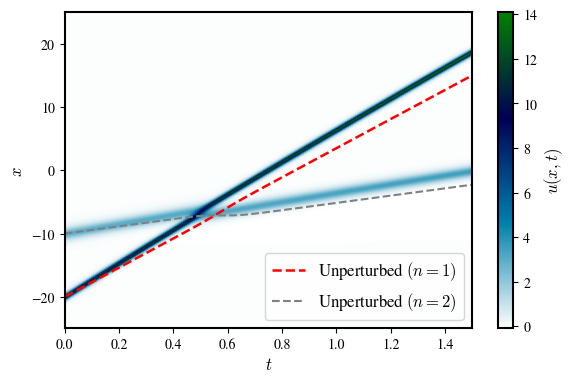

In [26]:
perturbed_collision_config = load_config("configs/kdv_soliton_collision_perturbed_v0.txt")
perturbed_collision_output = "outputs/kdv_soliton_collision_perturbed_v0.nc"

if not os.path.exists(perturbed_collision_output):
    run_perturbed_scenario(perturbed_collision_config, output_dir="outputs", verbose=True, n_cores=None)

with Dataset(perturbed_collision_output) as nc:
    x = nc["x"][:].data
    t = nc["t"][:].data
    u = nc["u"][:].data
    eta = nc.eta
    equation = nc.equation
    mass_error = nc.mass_error
    momentum_error = nc.momentum_error
    energy_error = nc.energy_error

# Compare to unperturbed two-soliton trajectories with the KdV collision phase shift.
fast_speed = perturbed_collision_config["eps"]*perturbed_collision_config["amplitude_1"]/3.0
slow_speed = perturbed_collision_config["eps"]*perturbed_collision_config["amplitude_2"]/3.0
fast_base = perturbed_collision_config["position_1"] + fast_speed*t
slow_base = perturbed_collision_config["position_2"] + slow_speed*t

k_fast = np.sqrt(perturbed_collision_config["amplitude_1"]/2.0)
k_slow = np.sqrt(perturbed_collision_config["amplitude_2"]/2.0)
phase = np.log((k_fast + k_slow)/(k_fast - k_slow))
fast_shift = phase/k_fast
slow_shift = -phase/k_slow
collision_time = (
    (perturbed_collision_config["position_2"] - perturbed_collision_config["position_1"])
    /(fast_speed - slow_speed)
)
transition_width = (
    perturbed_collision_config["width_1"] + perturbed_collision_config["width_2"]
)/(fast_speed - slow_speed)
phase_blend = 0.5*(1.0 + np.tanh((t - collision_time)/transition_width))
fast_path = fast_base + fast_shift*phase_blend
slow_path = slow_base + slow_shift*phase_blend

# Plotterino
fig, ax = plt.subplots(1, figsize=(6,4))

pc = ax.pcolormesh(t, x, u.T, cmap="ocean_r", shading="gouraud")
ax.plot(t, fast_path, color="red", lw=1.8, linestyle="--", label="Unperturbed $(n=1)$")
ax.plot(t, slow_path, color="gray", lw=1.5, linestyle="--", label="Unperturbed $(n=2)$")
ax.set_ylabel(r"$x$")
ax.set_xlabel(r"$t$")
#ax.set_ylim([-18,14])
ax.legend(loc="lower right")
fig.colorbar(pc, ax=ax, label=r"$u(x,t)$")

plt.tight_layout()
plt.show()

kdv_soliton_collision_perturbed_v1: u: (200, 1024) | energy_error = 6.46e-01
kdv_soliton_collision_perturbed_v2: u: (200, 1024) | energy_error = 6.56e-01


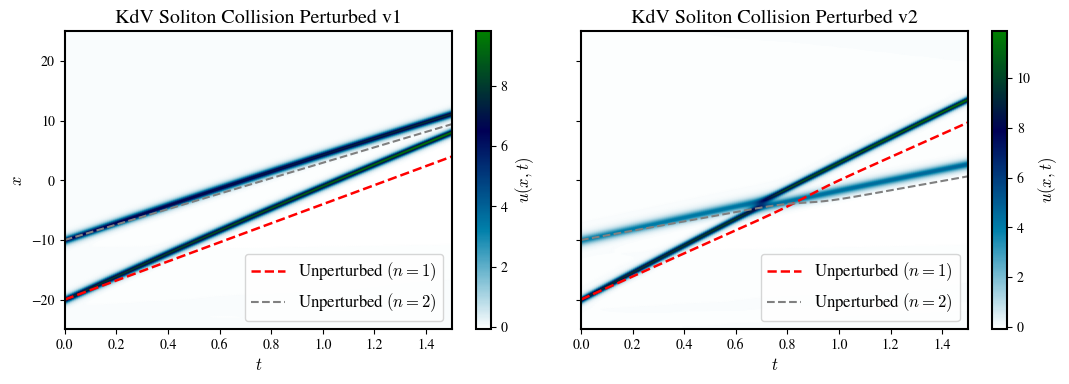

In [27]:
# Also generate two nearby perturbed trajectories (v1 uses kappas = (2.0,1.8), v2 uses kappas = (2.2,1.4))
nearby_perturbed_collisions = ["kdv_soliton_collision_perturbed_v1", "kdv_soliton_collision_perturbed_v2"]

fig, axes = plt.subplots(1, len(nearby_perturbed_collisions), figsize=(11, 4), sharey=True)

for name, ax in zip(nearby_perturbed_collisions, axes):
    config = load_config(f"configs/{name}.txt")
    output = f"outputs/{name}.nc"

    if not os.path.exists(output):
        run_perturbed_scenario(config, output_dir="outputs", verbose=True, n_cores=None)

    with Dataset(output) as nc:
        x = nc["x"][:].data
        t = nc["t"][:].data
        u = nc["u"][:].data
        print(f"{name}: u: {u.shape} | energy_error = {nc.energy_error:.2e}")

    # Compare to unperturbed two-soliton trajectories with the KdV collision phase shift.
    fast_speed = config["eps"]*config["amplitude_1"]/3.0
    slow_speed = config["eps"]*config["amplitude_2"]/3.0
    fast_base = config["position_1"] + fast_speed*t
    slow_base = config["position_2"] + slow_speed*t

    k_fast = np.sqrt(config["amplitude_1"]/2.0)
    k_slow = np.sqrt(config["amplitude_2"]/2.0)
    phase = np.log((k_fast + k_slow)/(k_fast - k_slow))
    fast_shift = phase/k_fast
    slow_shift = -phase/k_slow
    collision_time = (
        (config["position_2"] - config["position_1"])
        /(fast_speed - slow_speed)
    )
    transition_width = (
        config["width_1"] + config["width_2"]
    )/(fast_speed - slow_speed)
    phase_blend = 0.5*(1.0 + np.tanh((t - collision_time)/transition_width))
    fast_path = fast_base + fast_shift*phase_blend
    slow_path = slow_base + slow_shift*phase_blend

    pc = ax.pcolormesh(t, x, u.T, cmap="ocean_r", shading="gouraud")
    ax.plot(t, fast_path, color="red", lw=1.8, linestyle="--", label="Unperturbed $(n=1)$")
    ax.plot(t, slow_path, color="gray", lw=1.5, linestyle="--", label="Unperturbed $(n=2)$")
    ax.set_xlabel(r"$t$")
    ax.set_title(config["scenario_name"])
    #ax.set_ylim([-18,14])
    ax.legend(loc="lower right")
    fig.colorbar(pc, ax=ax, label=r"$u(x,t)$")

axes[0].set_ylabel(r"$x$")

plt.tight_layout()
plt.show()